# GRDC
<!-- markdownlint-disable MD013 -->
Debugging loading [GRDC](https://portal.grdc.bafg.de/applications/public.html?publicuser=PublicUser#dataDownload/Stations) data.

Replaced by functions in `src.datasources.grdc`

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import fsspec

import ocha_stratus as stratus
import xarray as xr

from src.constants import *

In [3]:
blob_name = f"{PROJECT_PREFIX}/raw/grdc/GRDC-Daily.nc"

In [4]:
url = stratus.get_container_client().get_blob_client(blob_name).url

In [5]:
fs = fsspec.filesystem("https")

In [6]:
ds = xr.open_dataset(fs.open(url), engine="h5netcdf", chunks={})

In [12]:
ds.compute()

<xarray.Dataset> Size: 3MB
Dimensions:              (time: 35232, id: 17)
Coordinates:
  * time                 (time) datetime64[ns] 282kB 1929-01-01 ... 2025-06-17
  * id                   (id) int64 136B 1234050 1234080 ... 1234700 1237500
Data variables:
    runoff_mean          (time, id) float32 2MB nan nan nan nan ... nan nan nan
    area                 (id) float32 68B 7.5e+03 4.49e+04 ... 4.8e+03 1.15e+05
    country              (id) <U2 136B 'NE' 'NE' 'NE' 'NE' ... 'NE' 'NE' 'NE'
    geo_x                (id) float32 68B 0.3 0.6 0.9833 0.75 ... 7.17 7.22 12.6
    geo_y                (id) float32 68B 14.62 14.75 14.62 ... 13.15 13.28
    geo_z                (id) float32 68B -999.0 227.0 -999.0 ... 378.0 298.0
    owneroforiginaldata  (id) <U99 7kB 'Initial dataset collected in the fram...
    river_name           (id) <U20 1kB 'GOROUOL' 'GOROUOL' ... 'KOMADUGU YOBE'
    station_name         (id) <U22 1kB 'DOLBEL' 'ALCONGUI' ... 'BAGARA DIFFA'
    timezone             (id) float32 68B 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
Attributes:
    title:          Mean daily discharge (Q)
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Download from GRDC Database, 05/08/2025
    missing_value:  -999.000

In [16]:
df = ds.to_dataframe().reset_index()

In [17]:
df

,time,id,runoff_mean,area,country,geo_x,geo_y,geo_z,owneroforiginaldata,river_name,station_name,timezone
0,1929-01-01,1234050,NaN,7500.0,NE,0.3000,14.6200,-999.0,Initial dataset collected in the framework of ...,GOROUOL,DOLBEL,1.0
1,1929-01-01,1234080,NaN,44900.0,NE,0.6000,14.7500,227.0,Initial dataset collected in the framework of ...,GOROUOL,ALCONGUI,1.0
2,1929-01-01,1234090,NaN,-999.0,NE,0.9833,14.6167,-999.0,Niger - Niger Basin Authority (NBA),RIVER NIGER,KANDADJI,1.0
3,1929-01-01,1234100,NaN,2750.0,NE,0.7500,14.0200,-999.0,Initial dataset collected in the framework of ...,DARGOL,TERA,1.0
4,1929-01-01,1234120,NaN,6940.0,NE,1.4700,13.8500,198.0,Initial dataset collected in the framework of ...,DARGOL,KAKASSI,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
598939,2025-06-17,1234550,NaN,824.0,NE,5.3700,14.5000,308.0,Initial dataset collected in the framework of ...,KORI DE BADEGUICHERI,BADEGUICHERI,1.0
598940,2025-06-17,1234650,NaN,8800.0,NE,6.7700,13.6700,313.0,Initial dataset collected in the framework of ...,RIVER MARADI,GUINDAM ROUMDJI,1.0
598941,2025-06-17,1234680,NaN,5400.0,NE,7.1700,13.3200,355.0,Initial dataset collected in the framework of ...,RIVER MARADI,MADAROUNFA,1.0
598942,2025-06-17,1234700,NaN,4800.0,NE,7.2200,13.1500,378.0,Initial dataset collected in the framework of ...,RIVER MARADI,NIELLOUA,1.0


In [18]:
df[df["station_name"].str.startswith("G")]

,time,id,runoff_mean,area,country,geo_x,geo_y,geo_z,owneroforiginaldata,river_name,station_name,timezone
5,1929-01-01,1234130,NaN,38750.0,NE,1.6167,13.7333,287.0,Niger - Niger Basin Authority (NBA),SIRBA,GARBE-KOUROU,1.0
13,1929-01-01,1234650,NaN,8800.0,NE,6.7700,13.6700,313.0,Initial dataset collected in the framework of ...,RIVER MARADI,GUINDAM ROUMDJI,1.0
22,1929-01-02,1234130,NaN,38750.0,NE,1.6167,13.7333,287.0,Niger - Niger Basin Authority (NBA),SIRBA,GARBE-KOUROU,1.0
30,1929-01-02,1234650,NaN,8800.0,NE,6.7700,13.6700,313.0,Initial dataset collected in the framework of ...,RIVER MARADI,GUINDAM ROUMDJI,1.0
39,1929-01-03,1234130,NaN,38750.0,NE,1.6167,13.7333,287.0,Niger - Niger Basin Authority (NBA),SIRBA,GARBE-KOUROU,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
598906,2025-06-15,1234650,NaN,8800.0,NE,6.7700,13.6700,313.0,Initial dataset collected in the framework of ...,RIVER MARADI,GUINDAM ROUMDJI,1.0
598915,2025-06-16,1234130,NaN,38750.0,NE,1.6167,13.7333,287.0,Niger - Niger Basin Authority (NBA),SIRBA,GARBE-KOUROU,1.0
598923,2025-06-16,1234650,NaN,8800.0,NE,6.7700,13.6700,313.0,Initial dataset collected in the framework of ...,RIVER MARADI,GUINDAM ROUMDJI,1.0
598932,2025-06-17,1234130,NaN,38750.0,NE,1.6167,13.7333,287.0,Niger - Niger Basin Authority (NBA),SIRBA,GARBE-KOUROU,1.0


In [19]:
garbekourou_id = 1234130

In [27]:
cols = ["time", "runoff_mean"]

In [28]:
dff = df[df["id"] == garbekourou_id][cols].dropna()

<Axes: xlabel='time'>

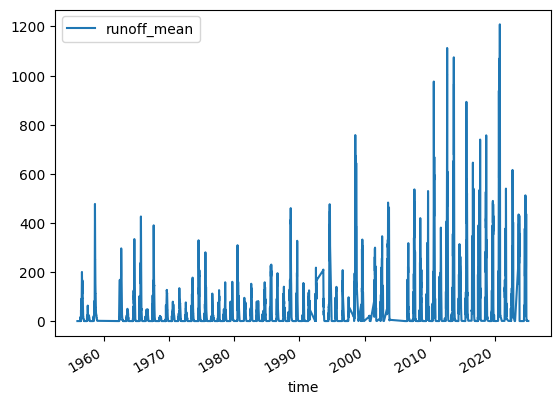

In [30]:
dff.set_index("time").plot()

In [34]:
ds

<xarray.Dataset> Size: 3MB
Dimensions:              (time: 35232, id: 17)
Coordinates:
  * time                 (time) datetime64[ns] 282kB 1929-01-01 ... 2025-06-17
  * id                   (id) int64 136B 1234050 1234080 ... 1234700 1237500
Data variables:
    runoff_mean          (time, id) float32 2MB dask.array<chunksize=(35232, 17), meta=np.ndarray>
    area                 (id) float32 68B dask.array<chunksize=(17,), meta=np.ndarray>
    country              (id) <U2 136B dask.array<chunksize=(17,), meta=np.ndarray>
    geo_x                (id) float32 68B dask.array<chunksize=(17,), meta=np.ndarray>
    geo_y                (id) float32 68B dask.array<chunksize=(17,), meta=np.ndarray>
    geo_z                (id) float32 68B dask.array<chunksize=(17,), meta=np.ndarray>
    owneroforiginaldata  (id) <U99 7kB dask.array<chunksize=(17,), meta=np.ndarray>
    river_name           (id) <U20 1kB dask.array<chunksize=(17,), meta=np.ndarray>
    station_name         (id) <U22 1kB dask.array<chunksize=(17,), meta=np.ndarray>
    timezone             (id) float32 68B dask.array<chunksize=(17,), meta=np.ndarray>
Attributes:
    title:          Mean daily discharge (Q)
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Download from GRDC Database, 05/08/2025
    missing_value:  -999.000

In [39]:
ds.sel(id=garbekourou_id).to_dataframe().reset_index()[cols].copy()

,time,runoff_mean
0,1929-01-01,NaN
1,1929-01-02,NaN
2,1929-01-03,NaN
3,1929-01-04,NaN
4,1929-01-05,NaN
...,...,...
35227,2025-06-13,NaN
35228,2025-06-14,NaN
35229,2025-06-15,NaN
35230,2025-06-16,NaN
